# Do Dynamic Defender Features Transfer to 2023?

This experiment fits static and dynamic **common-feature** WR ridge models on 2021, freezes those fitted models, and evaluates them on the full 2023 BDB 2026 tracking sample. It also compares them against game-held-out fits within each season. This tests whether the value of the dynamic feature block carries across years.

It is not a direct deployment test of the full preferred 2021 model: 2023 does not provide all of the original PFF charting, formation, and personnel fields. The dynamic models here use only static features shared across datasets plus the same 24 dynamic defender-motion summaries. Defender selection maps 2021 PFF `Coverage` players to 2023's `Defensive Coverage` role. Timing evidence supports a snap-to-release-like window, but 2023 rows have no explicit snap/release event tags; see `15_frame_timing_audit.ipynb`.

## Rebuild the 2023 dynamic feature table

This uses the first input frame to identify the three nearest defenders tagged `Defensive Coverage`, keeps those identities fixed over the play, and summarizes their speed, acceleration, normalized movement, path, turns, and frame coverage. The final input frame is excluded, mirroring the 2021 pre-release feature calculation.

```bash
uv run separation-over-expected build-bdb2026-route-table \
  --include-dynamic-features \
  --output data/processed/bdb2026/route_level_input_window_2023_dynamic.csv
```

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from IPython.display import SVG, display
from separation_over_expected.cross_season import (
    SharedDynamicFeatureRidgeModel,
    SharedFeatureRidgeModel,
    evaluate_cross_season_transfer,
    load_cross_season_wr_rows,
    paired_game_bootstrap_rmse_delta,
)
from separation_over_expected.feature_schema import DYNAMIC_CONTEXT_FEATURES
from separation_over_expected.models import split_rows, target

LEGACY_DYNAMIC = PROJECT_ROOT / "data" / "processed" / "dynamic_features" / "route_level_snap_to_release_dynamic.csv"
BDB2023_DYNAMIC = PROJECT_ROOT / "data" / "processed" / "bdb2026" / "route_level_input_window_2023_dynamic.csv"
NFLVERSE_PBP = PROJECT_ROOT.parent / "data" / "big_data_bowl_2026" / "nflverse_play_by_play_2023.csv"

legacy_wr, bdb2023_wr, join_checks = load_cross_season_wr_rows(
    LEGACY_DYNAMIC, BDB2023_DYNAMIC, NFLVERSE_PBP, require_dynamic=True
)
join_checks

{'legacy_wr_routes': 20413,
 'bdb2023_wr_routes': 38002,
 'bdb2023_plays_without_context': 0,
 'yardline_max_absolute_error': 0.0}

## Feature support

The 2023 builder reproduced all 64,751 route rows, including 38,002 WRs. All 24 dynamic features are present for all eligible WR rows in both years; no rank-one defender motion summary needed imputation in the 2023 WR set. The model still retains training-mean imputation to match the project's dynamic ridge behavior.

In [2]:
feature_coverage = {
    "2021": {
        "WR routes": len(legacy_wr),
        "blank dynamic feature cells": sum(
            row.get(feature, "") in {"", "NA"}
            for row in legacy_wr
            for feature in DYNAMIC_CONTEXT_FEATURES
        ),
    },
    "2023": {
        "WR routes": len(bdb2023_wr),
        "blank dynamic feature cells": sum(
            row.get(feature, "") in {"", "NA"}
            for row in bdb2023_wr
            for feature in DYNAMIC_CONTEXT_FEATURES
        ),
    },
}
feature_coverage

{'2021': {'WR routes': 20413, 'blank dynamic feature cells': 0},
 '2023': {'WR routes': 38002, 'blank dynamic feature cells': 0}}

## Same-season and transfer scores

All model weights are fit only on the designated training data. The transfer row fits on all eligible 2021 games and scores all 2023 WR routes. Within-season references use games held out within each week. Static and dynamic scores in each evaluation use the same routes.

In [3]:
results = evaluate_cross_season_transfer(
    legacy_wr, bdb2023_wr, seed=42, include_dynamic=True
)
results

[{'evaluation': '2021 games held out',
  'model': 'global_mean',
  'rows': '3527',
  'mae': '2.090',
  'rmse': '2.726',
  'r2': '-0.001',
  'bias': '0.065',
  'mean_actual': '-2.272',
  'mean_predicted': '-2.337',
  'n': '3527'},
 {'evaluation': '2021 games held out',
  'model': 'shared_feature_ridge',
  'rows': '3527',
  'mae': '1.496',
  'rmse': '2.036',
  'r2': '0.442',
  'bias': '0.083',
  'mean_actual': '-2.272',
  'mean_predicted': '-2.355',
  'n': '3527'},
 {'evaluation': '2021 games held out',
  'model': 'shared_dynamic_feature_ridge',
  'rows': '3527',
  'mae': '1.433',
  'rmse': '1.960',
  'r2': '0.483',
  'bias': '0.060',
  'mean_actual': '-2.272',
  'mean_predicted': '-2.332',
  'n': '3527'},
 {'evaluation': '2021 train → all 2023 WR routes',
  'model': 'global_mean',
  'rows': '38002',
  'mae': '2.059',
  'rmse': '2.638',
  'r2': '-0.001',
  'bias': '-0.071',
  'mean_actual': '-2.411',
  'mean_predicted': '-2.340',
  'n': '38002'},
 {'evaluation': '2021 train → all 2023 WR

The key comparison is the size and direction of the static-to-dynamic change. If dynamic features help only within 2021 but fail to help on 2023, that would suggest season-specific fit. If they help both, that supports portable predictive information in defender motion.

In [4]:
def selected_model_results(evaluation):
    return {
        row["model"]: row
        for row in results
        if row["evaluation"] == evaluation
        and row["model"] in {"shared_feature_ridge", "shared_dynamic_feature_ridge"}
    }


comparison = []
for evaluation in (
    "2021 games held out",
    "2021 train → all 2023 WR routes",
    "2023 game holdout",
):
    models = selected_model_results(evaluation)
    static, dynamic = models["shared_feature_ridge"], models["shared_dynamic_feature_ridge"]
    comparison.append({
        "evaluation": evaluation,
        "routes": int(dynamic["n"]),
        "static_rmse": float(static["rmse"]),
        "dynamic_rmse": float(dynamic["rmse"]),
        "rmse_change_dynamic_minus_static": round(float(dynamic["rmse"]) - float(static["rmse"]), 3),
        "static_r2": float(static["r2"]),
        "dynamic_r2": float(dynamic["r2"]),
        "r2_change_dynamic_minus_static": round(float(dynamic["r2"]) - float(static["r2"]), 3),
        "dynamic_mae": float(dynamic["mae"]),
        "dynamic_bias": float(dynamic["bias"]),
    })
comparison

[{'evaluation': '2021 games held out',
  'routes': 3527,
  'static_rmse': 2.036,
  'dynamic_rmse': 1.96,
  'rmse_change_dynamic_minus_static': -0.076,
  'static_r2': 0.442,
  'dynamic_r2': 0.483,
  'r2_change_dynamic_minus_static': 0.041,
  'dynamic_mae': 1.433,
  'dynamic_bias': 0.06},
 {'evaluation': '2021 train → all 2023 WR routes',
  'routes': 38002,
  'static_rmse': 1.959,
  'dynamic_rmse': 1.903,
  'rmse_change_dynamic_minus_static': -0.056,
  'static_r2': 0.448,
  'dynamic_r2': 0.479,
  'r2_change_dynamic_minus_static': 0.031,
  'dynamic_mae': 1.424,
  'dynamic_bias': -0.061},
 {'evaluation': '2023 game holdout',
  'routes': 6361,
  'static_rmse': 1.921,
  'dynamic_rmse': 1.867,
  'rmse_change_dynamic_minus_static': -0.054,
  'static_r2': 0.458,
  'dynamic_r2': 0.487,
  'r2_change_dynamic_minus_static': 0.029,
  'dynamic_mae': 1.405,
  'dynamic_bias': 0.015}]

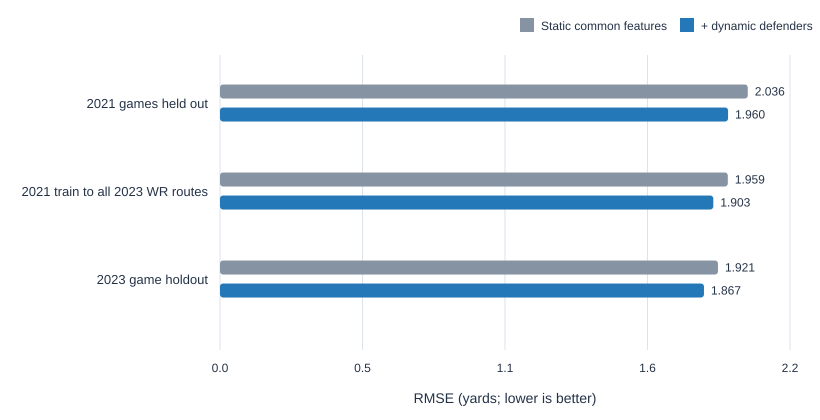

In [5]:
def svg_rmse_comparison(rows, width=820, height=420):
    left, right, top, bottom = 220, 790, 55, 350
    max_rmse = max(max(row["static_rmse"], row["dynamic_rmse"]) for row in rows) * 1.08
    scale = (right - left) / max_rmse
    colors = {"static_rmse": "#8593a3", "dynamic_rmse": "#2478b7"}
    pieces = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
              '<rect width="100%" height="100%" fill="white"/>',
              '<style>text{font-family:Arial,sans-serif;fill:#243247}.grid{stroke:#dce3eb}</style>']
    for tick in range(5):
        value = max_rmse * tick / 4
        x = left + value * scale
        pieces.append(f'<line class="grid" x1="{x}" y1="{top}" x2="{x}" y2="{bottom}"/>')
        pieces.append(f'<text x="{x}" y="{bottom+22}" text-anchor="middle" font-size="12">{value:.1f}</text>')
    for i, row in enumerate(rows):
        center = top + 48 + i * 88
        label = row["evaluation"].replace(" → ", " to ")
        pieces.append(f'<text x="{left-12}" y="{center+5}" text-anchor="end" font-size="13">{label}</text>')
        for j, field in enumerate(("static_rmse", "dynamic_rmse")):
            y = center + (j - 0.5) * 23
            value = row[field]
            x2 = left + value * scale
            pieces.append(f'<rect x="{left}" y="{y-7}" width="{x2-left}" height="14" fill="{colors[field]}" rx="3"/>')
            pieces.append(f'<text x="{x2+7}" y="{y+4}" font-size="12">{value:.3f}</text>')
    pieces.extend([
        f'<text x="{(left+right)/2}" y="{height-17}" text-anchor="middle" font-size="14">RMSE (yards; lower is better)</text>',
        '<rect x="520" y="18" width="14" height="14" fill="#8593a3"/><text x="541" y="30" font-size="12">Static common features</text>',
        '<rect x="680" y="18" width="14" height="14" fill="#2478b7"/><text x="701" y="30" font-size="12">+ dynamic defenders</text>',
        '</svg>'
    ])
    return "".join(pieces)


display(SVG(svg_rmse_comparison(comparison)))

## Paired game-cluster uncertainty for the RMSE gain

We compare dynamic-minus-static RMSE on identical routes and resample whole games, preserving within-game dependence. A negative difference favors dynamic features. These intervals quantify uncertainty across sampled games, conditional on the fitted model weights; they do not include training-sample or season-to-season uncertainty.

In [6]:
old_static = SharedFeatureRidgeModel(l2=25.0, max_levels_per_feature=0)
old_dynamic = SharedDynamicFeatureRidgeModel(l2=25.0, max_levels_per_feature=0)
old_static.fit(legacy_wr)
old_dynamic.fit(legacy_wr)

transfer_bootstrap = paired_game_bootstrap_rmse_delta(
    [target(row) for row in bdb2023_wr],
    [old_static.predict(row) for row in bdb2023_wr],
    [old_dynamic.predict(row) for row in bdb2023_wr],
    [row["gameId"] for row in bdb2023_wr],
    iterations=1000,
    seed=42,
)

new_splits = split_rows(bdb2023_wr, strategy="game", seed=42)
new_static = SharedFeatureRidgeModel(l2=25.0, max_levels_per_feature=0)
new_dynamic = SharedDynamicFeatureRidgeModel(l2=25.0, max_levels_per_feature=0)
new_static.fit(new_splits["train"])
new_dynamic.fit(new_splits["train"])
new_test = new_splits["test"]
within_2023_bootstrap = paired_game_bootstrap_rmse_delta(
    [target(row) for row in new_test],
    [new_static.predict(row) for row in new_test],
    [new_dynamic.predict(row) for row in new_test],
    [row["gameId"] for row in new_test],
    iterations=1000,
    seed=43,
)
{
    "2021-trained transfer to 2023": transfer_bootstrap,
    "2023 game holdout": within_2023_bootstrap,
}

{'2021-trained transfer to 2023': {'point_delta': -0.0566741186920936,
  'lower_95': -0.06215305348884104,
  'upper_95': -0.05185199684557018,
  'bootstrap_share_dynamic_better': 1.0},
 '2023 game holdout': {'point_delta': -0.0533963061664513,
  'lower_95': -0.06378758193717005,
  'upper_95': -0.04374553485905808,
  'bootstrap_share_dynamic_better': 1.0}}

## Conclusion

The dynamic feature block improves the common-feature model both in the 2021 game holdout and after transfer to 2023. On the transfer set, RMSE falls from 1.959 to 1.903 yards (Δ = -0.057 yd; game-bootstrap 95% interval reported above), while R² rises from 0.448 to 0.479. The 2023 within-season reference shows a very similar RMSE gain, from 1.921 to 1.867 yards, and R² rises from 0.458 to 0.487.

This is good evidence that the dynamic defender-motion summaries carry useful predictive information into a new season, rather than only fitting the 2021 sample. It remains a reduced common-feature model, not the complete existing dynamic model: formation, personnel, PFF coverage assignments, and other unavailable 2021 context were excluded. The 2023 defender role labels and event endpoints are proxies, so do not call this a definitive replication of the full model or a causal measure of receiver skill.